In [23]:
### Setting Environment ###

import subprocess
import os

result = subprocess.run('bash -c "source /etc/network_turbo && env | grep proxy"', shell=True, capture_output=True, text=True)
output = result.stdout
for line in output.splitlines():
    if '=' in line:
        var, value = line.split('=', 1)
        os.environ[var] = value

In [24]:
### Setting Environment ###

%pip install requests
%pip install pathlib
import requests
from pathlib import Path

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )
    open("notebook_utils.py", "w").write(r.text)

if not Path("cmd_helper.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py",
    )
    open("cmd_helper.py", "w").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("depth-anything-v2.ipynb")

In [25]:
### Download Depth Model ###

from cmd_helper import clone_repo

clone_repo("https://huggingface.co/spaces/depth-anything/Depth-Anything-V2")

PosixPath('Depth-Anything-V2')

In [26]:
### Setting Environment ###

import platform

%pip install -q "openvino>=2024.2.0" "datasets>=2.14.6" "nncf>=2.11.0" "tqdm" "matplotlib>=3.4"
%pip install -q "typing-extensions>=4.9.0" eval-type-backport "gradio>=4.19" gradio_imageslider
%pip install -q torch torchvision "opencv-python" huggingface_hub --extra-index-url https://download.pytorch.org/whl/cpu

if platform.system() == "Darwin":
    %pip install -q "numpy<2.0.0"
if platform.python_version_tuple()[1] in ["8", "9"]:
    %pip install -q "gradio-imageslider<=0.0.17" "typing-extensions>=4.9.0"

In [27]:
### Setting up Parameters for Depth Model ###

attention_file_path = Path("./Depth-Anything-V2/depth_anything_v2/dinov2_layers/attention.py")
orig_attention_path = attention_file_path.parent / ("orig_" + attention_file_path.name)

if not orig_attention_path.exists():
    attention_file_path.rename(orig_attention_path)

    with orig_attention_path.open("r") as f:
        data = f.read()
        data = data.replace("XFORMERS_AVAILABLE = True", "XFORMERS_AVAILABLE = False")
        with attention_file_path.open("w") as out_f:
            out_f.write(data)

In [ ]:
### Image Input ###

from pathlib import Path
from PIL import Image

from notebook_utils import download_file, device_widget, quantization_widget
##This code below is for downloading through links
#if not Path("furseal.png").exists():
    #download_file(
        #"https://github.com/openvinotoolkit/openvino_notebooks/assets/29454499/3f779fc1-c1b2-4dec-915a-64dae510a2bb",
        #"furseal.png",
    #)
##This code can either refer to the name from the code above or through directory to find image or make a folder in the files where the code is located but the folder will be deleted when the code being run 
##So there are 2 methods to input image, one is to download through link, another is by through directory of the image you want to run the code on. 
# (note: if you want to run through the first method which is by the download link, after renaming it, you need to replace the image.open command from a directory to the name you gave in the download_file command)
input_image = Image.open("/content/Image_Input/maxresdefault.jpg").resize((600, 400))

In [29]:
### Download Depth Model Encoder ###

from huggingface_hub import hf_hub_download

encoder = "vits"
model_type = "Small"
model_id = f"depth_anything_v2_{encoder}"

model_path = hf_hub_download(repo_id=f"depth-anything/Depth-Anything-V2-{model_type}", filename=f"{model_id}.pth", repo_type="model")

In [30]:
### Input Image into Depth Model ###

import cv2
import torch
import torch.nn.functional as F
import numpy as np

from depth_anything_v2.dpt import DepthAnythingV2

model = DepthAnythingV2(encoder=encoder, features=64, out_channels=[48, 96, 192, 384])
model.load_state_dict(torch.load(model_path, map_location="cpu"))
model.eval()

raw_img = np.array(input_image)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_RGB2BGR)
image, (h, w) = model.image2tensor(raw_img)
image = image.to("cpu").to(torch.float32)

with torch.no_grad():
    depth = model.forward(image)

depth = F.interpolate(depth[:, None], (h, w), mode="bilinear", align_corners=True)[0, 0]

output = depth.cpu().numpy()

In [31]:
### Process Depth Image ###

from matplotlib import pyplot as plt
import numpy as np
import cv2


def get_depth_map(output, w, h):
    depth = cv2.resize(output, (w, h))

    depth = (depth - depth.min()) / (depth.max() - depth.min()) * 255.0
    depth = depth.astype(np.uint8)

    depth = cv2.applyColorMap(depth, cv2.COLORMAP_INFERNO)

    return depth

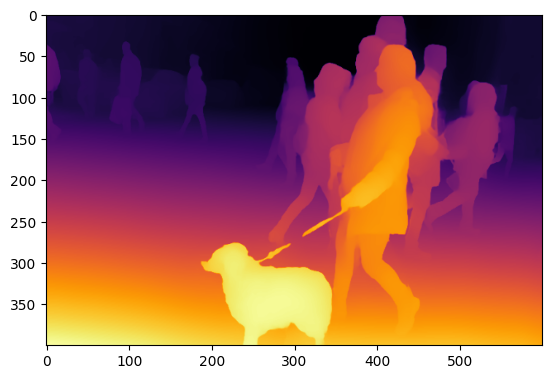

In [32]:
### Print Depth Model's image result ###

h, w = raw_img.shape[:-1]
res_depth = get_depth_map(output, w, h)
plt.imshow(res_depth[:, :, ::-1])
plt.savefig('depth.png')

In [33]:
### Download Segmentation(SAM) Model ###

!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

--2025-04-15 18:18:05--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.226.210.25, 13.226.210.78, 13.226.210.111, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.226.210.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth.2’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   123MB/s    in 31s     

2025-04-15 18:18:36 (79.7 MB/s) - ‘sam_vit_h_4b8939.pth.2’ saved [2564550879/2564550879]



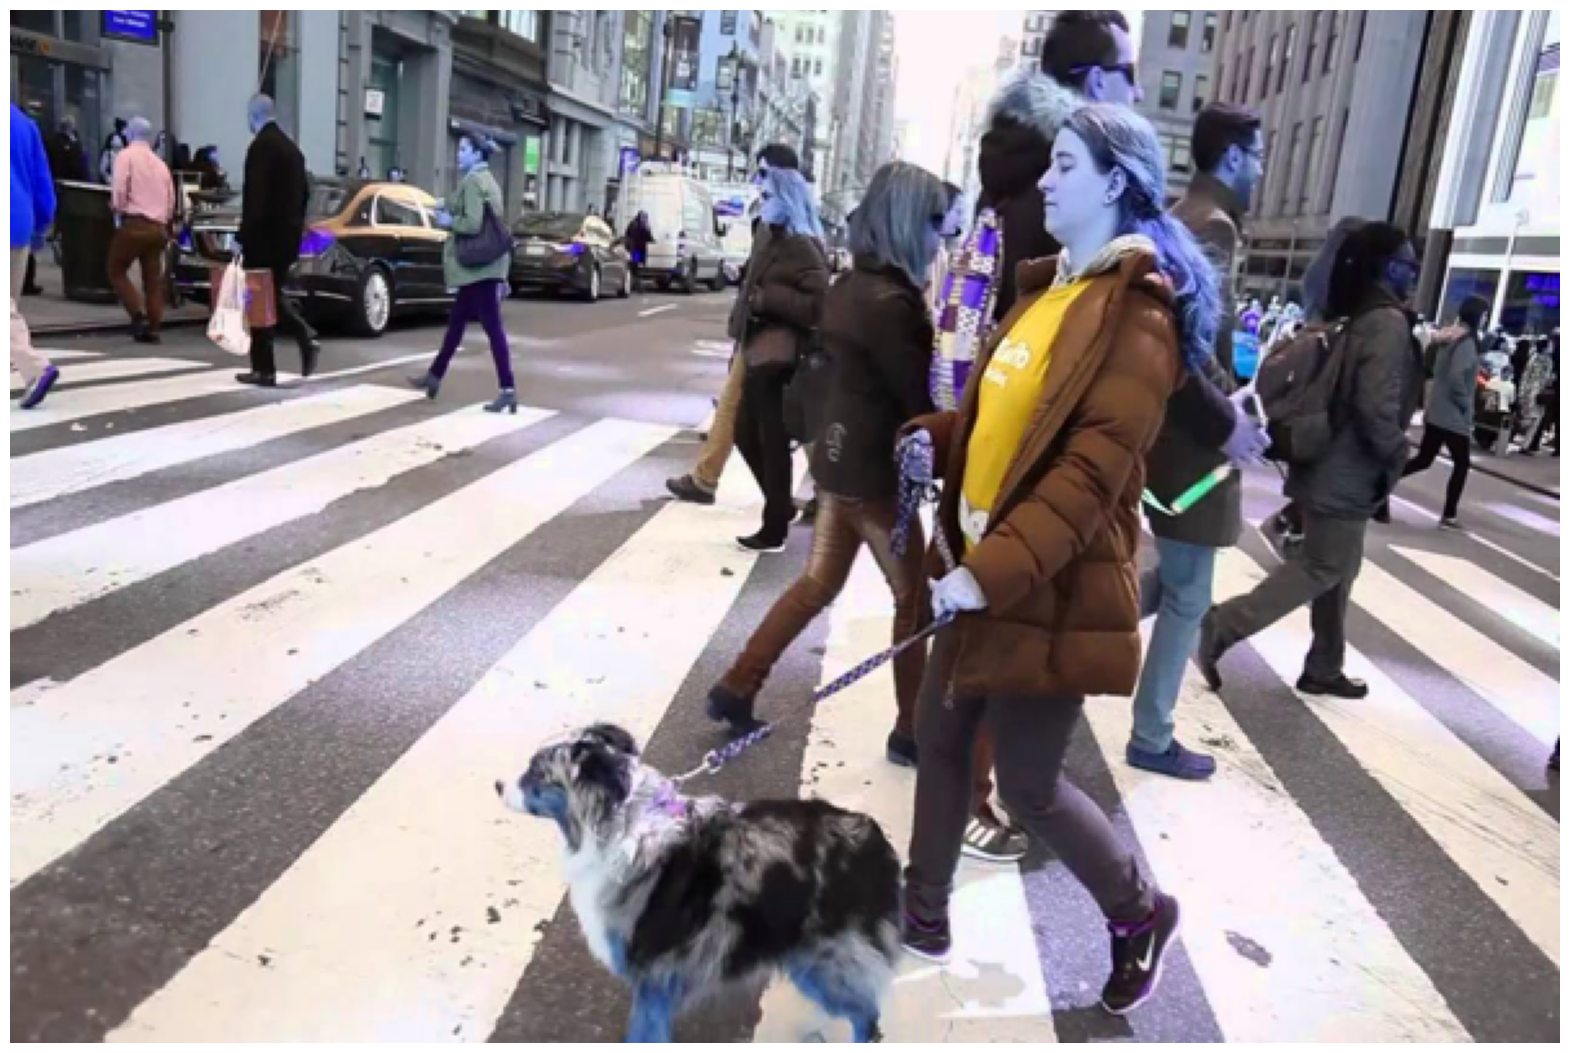

In [34]:
### Switch Image from input for RGB to BGR, set up image input for Segmentation Model ###

import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

raw_img = np.array(input_image)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_RGB2BGR)
# input_image = cv2.imread(image)
# input_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(20,20))
plt.imshow(raw_img)
plt.axis('off')
plt.show()

In [35]:
pip install segment_anything

In [36]:
### Load Parameters & Inference Image (Input Image into Segmentation(SAM) Model) ###

# import sys
# sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(sam)
masks = mask_generator.generate(raw_img)

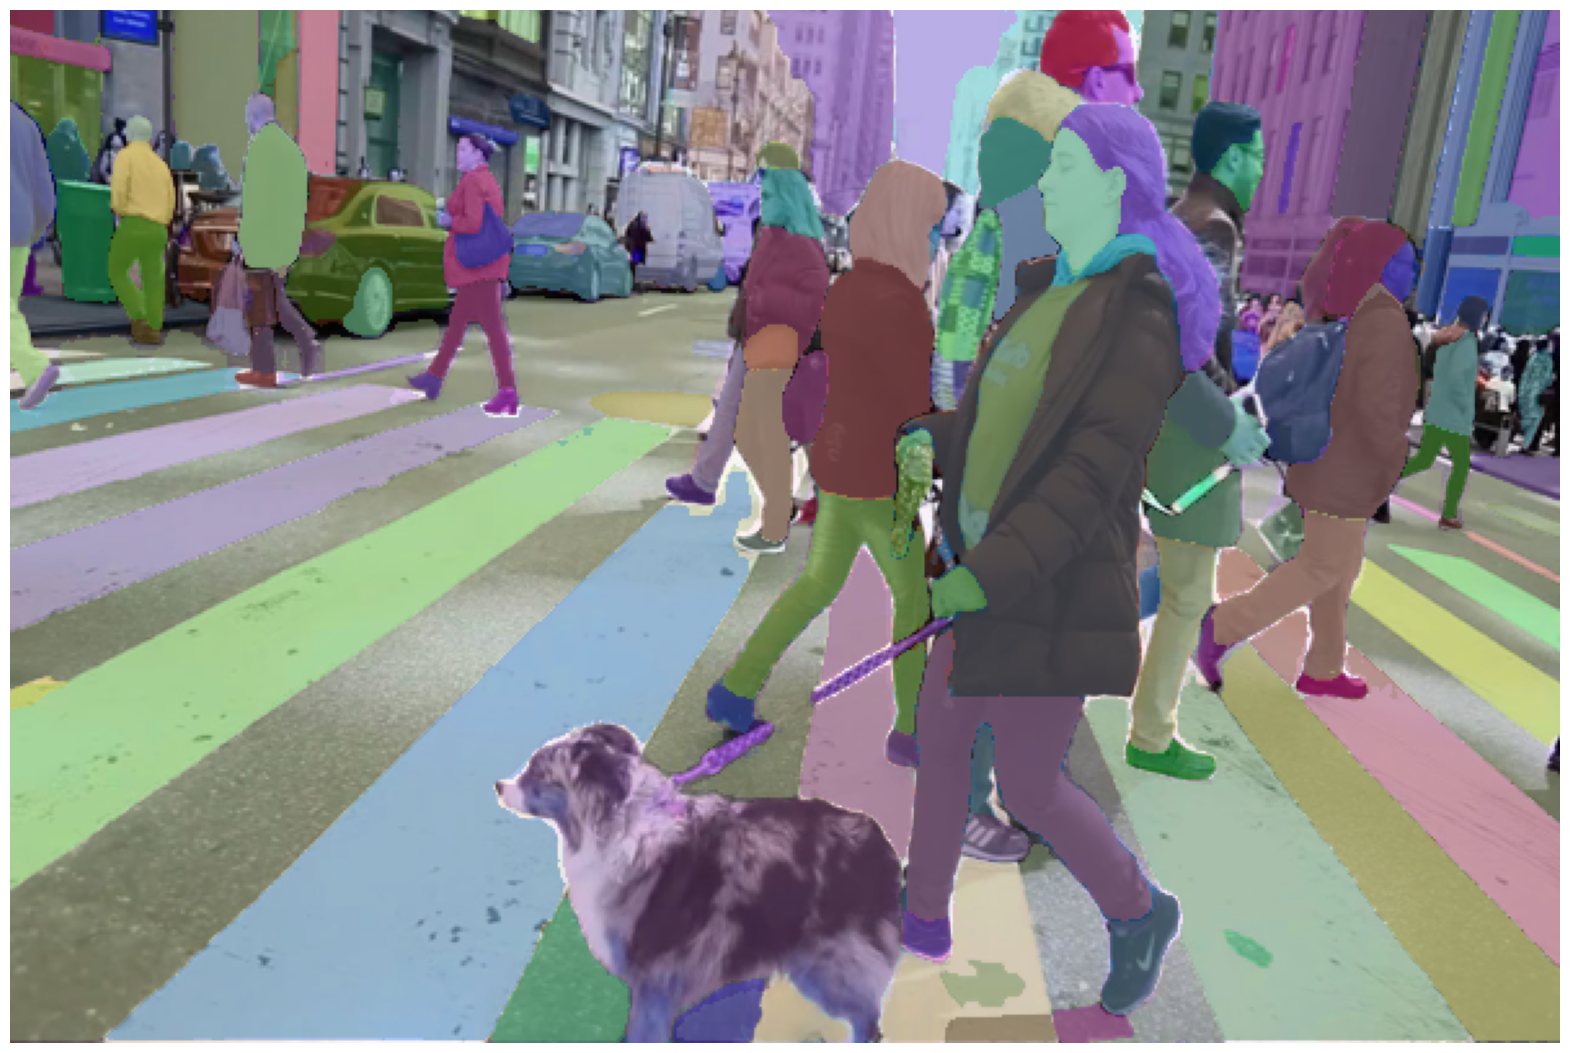

In [37]:
### Process Image in Segmentation(SAM) Model ###

import io
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    for ann in sorted_anns:
        m = ann['segmentation']
        img = np.ones((m.shape[0], m.shape[1], 3))
        color_mask = np.random.random((1, 3)).tolist()[0]
        for i in range(3):
            img[:,:,i] = color_mask[i]
        ax.imshow(np.dstack((img, m*0.35)))

### Print Segmentation Model's image result ###

plt.figure(figsize=(20,20))
plt.imshow(raw_img)
mask = show_anns(masks)
plt.axis('off')
buffer = io.BytesIO()
plt.savefig(buffer, format='png', bbox_inches='tight', pad_inches=0)
buffer.seek(0)
mask_image = Image.open(buffer)
mask_input = np.array(mask_image)
plt.savefig('mask.png',bbox_inches='tight', pad_inches=0)
plt.show()

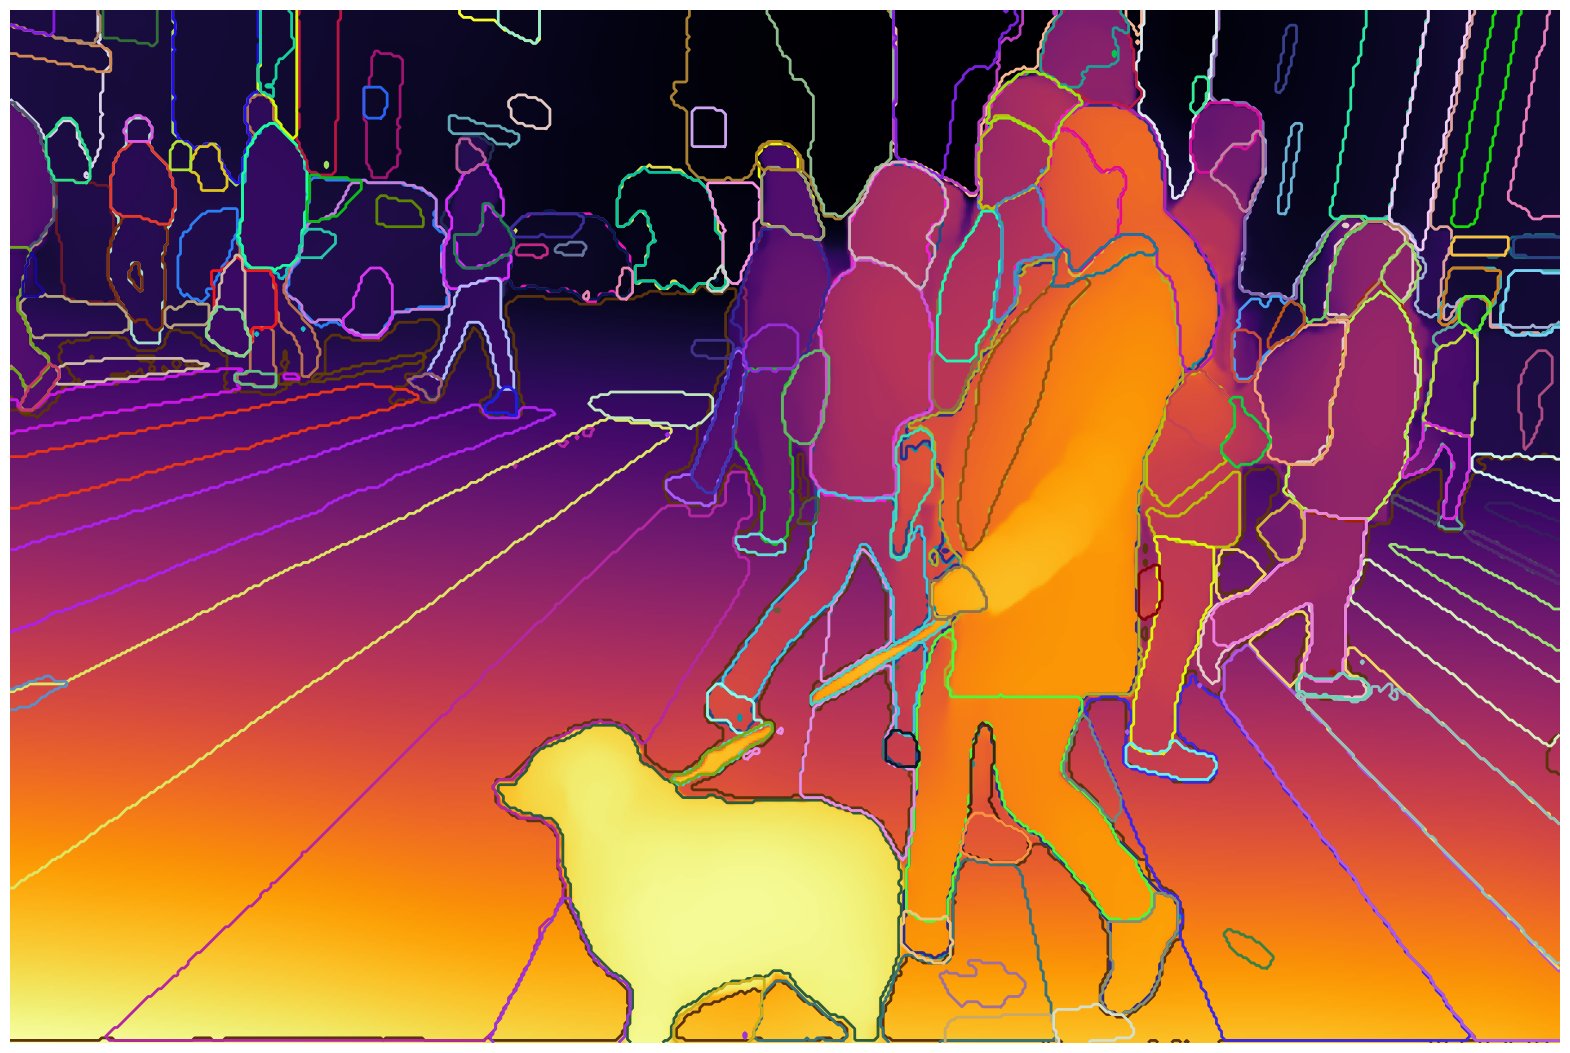

In [38]:
### Fusion Result of Segmentation and Depth Model ###
%pip install -q scikit-image
from skimage import measure
def show_anns_boundary(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    for ann in sorted_anns:
        m = ann['segmentation']
        color = np.random.random(3)
        contours = measure.find_contours(m, 0.5)
        for contour in contours:
            ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color=color)

### Print Fushion Model's image result ###

plt.figure(figsize=(20,20))
plt.imshow(res_depth[:, :, ::-1])
show_anns_boundary(masks)
plt.axis('off')

buffer = io.BytesIO()
plt.savefig(buffer, format='png', bbox_inches='tight', pad_inches=0)
buffer.seek(0)
mask_image = Image.open(buffer)
mask_input = np.array(mask_image)
plt.savefig('mask_boundary.png', bbox_inches='tight', pad_inches=0)
plt.show()

In [39]:
### Install LLM ###

!pip install -q openai

In [40]:
### Covert The image result from Fushion Model into an input LLM can read ###

import os
import base64
import io
from PIL import Image
from openai import OpenAI

# image_1 = Image.open(io.BytesIO(depth_image))
# image_2 = Image.open(io.BytesIO(mask))
image_1 = Image.fromarray(res_depth)
image_2 = Image.fromarray(mask_input)

def encode_image_to_base64(image):
    buffered = io.BytesIO()
    image.save(buffered, format=image.format or "PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode('utf-8')
    return img_str

image_base64_1 = encode_image_to_base64(image_1)
image_base64_2 = encode_image_to_base64(image_2)

In [ ]:
### Create QWEN LLM Function ###

from PIL import Image
from openai import OpenAI

def query_qwen(image_1, image_2, text_prompt):

    client = OpenAI(
        api_key = os.getenv("DASHSCOPE_API_KEY"),#os.getenv("DASHSCOPE_API_KEY"),
        base_url = "https://dashscope.aliyuncs.com/compatible-mode/v1",
    )


    completion = client.chat.completions.create(
        model="qwen-vl-max-latest",
        messages=[
            {"role": "system", "content": [{"type": "text", "text": "You are a helpful assistant."}]},
            {"role": "user", "content": [
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{image_1}"}},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{image_2}"}},
                {"type": "text", "text": text_prompt},
            ]},
        ],
    )

    print(completion.choices[0].message.content)

In [ ]:
### Import ChatGPT key for ChatGPT LLM ###

import os
#Enter your own openAI ChatGPT Key
os.environ['OPENAI_API_KEY'] = os.getenv("DASHSCOPE_API_KEY")

In [43]:
### Create ChatGPT LLM Function ###

from PIL import Image
from openai import OpenAI

def query_gpt(image_1, image_2, text_prompt):
    client = OpenAI()
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": text_prompt,
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{image_1}",
                        },
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{image_2}",
                        },
                    },
                ],
            }
        ],
        max_tokens=300,
    )
    print(response.choices[0])

In [44]:
### Call & Ask QWEN LLM Function ###

query_qwen(image_1=image_base64_1, image_2=image_base64_2, text_prompt="What are in these images? Is there any difference between them?")

Both images depict a scene where a person is walking a dog, with other people in the background. However, there are notable differences between the two images:

### 1. **Color Scheme and Style:**
   - **First Image:** 
     - The image uses a gradient of cool colors, primarily shades of blue and purple.
     - The style is more abstract and smooth, with softer edges and a less defined outline.
   - **Second Image:**
     - The image uses a gradient of warm colors, primarily shades of yellow, orange, and red.
     - The style is more vibrant and detailed, with sharp outlines and a higher contrast.

### 2. **Detail and Clarity:**
   - **First Image:** 
     - The details are less pronounced, and the figures appear more blended into the background.
     - The overall scene is more subdued and less distinct.
   - **Second Image:**
     - The details are more pronounced, with clear outlines around the figures and objects.
     - The scene is more vivid and distinct, making it easier to disc

In [45]:
### Call & Ask ChatGPT LLM Function ###

query_gpt(image_1=image_base64_1, image_2=image_base64_2, text_prompt="What are in these images? Is there any difference between them?")

Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='The images appear to be stylized representations of a street scene with people walking, and one person is holding a dog on a leash.\n\n1. The first image uses a gradient of colors, likely representing depth or some kind of segmentation, with figures appearing more in silhouette.\n\n2. The second image has a similar scene but with a more detailed contouring style, highlighting edges and separating different objects or regions clearly with colored outlines.\n\nThe main difference is in the style and detail: the first image emphasizes shapes and depth, while the second emphasizes outlines and edges.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))
